# 04 — Visualization Engine
**AutoAnalyst | Finance Module**

Auto-generates domain-aware charts based on dataset type.
- `timeseries`    → price + MA overlay, volume bars, return distribution, volatility
- `transactional` → category spend, monthly trend, city breakdown, day-of-week pattern
- `fundamental`   → sector market cap, profitability, EPS distribution, top companies

All charts saved as PNG to `outputs/charts/`
Charts also render inline in the notebook.

In [25]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Global chart style
plt.rcParams.update({
    'figure.facecolor' : '#0f0f0f',
    'axes.facecolor'   : '#1a1a1a',
    'axes.edgecolor'   : '#333333',
    'axes.labelcolor'  : '#cccccc',
    'axes.titlecolor'  : '#ffffff',
    'xtick.color'      : '#888888',
    'ytick.color'      : '#888888',
    'grid.color'       : '#2a2a2a',
    'grid.linewidth'   : 0.5,
    'text.color'       : '#cccccc',
    'font.family'      : 'monospace',
    'figure.titlesize' : 14,
})

COLORS = {
    'green'  : '#00ff88',
    'red'    : '#ff4444',
    'blue'   : '#4488ff',
    'yellow' : '#ffcc00',
    'purple' : '#aa44ff',
    'orange' : '#ff8844',
    'teal'   : '#00cccc',
    'gray'   : '#666666',
}
PALETTE = list(COLORS.values())

print('✅ Libraries loaded.')

✅ Libraries loaded.


In [26]:
# ── Cell 2: Config ────────────────────────────────────────────────────────────
DATASET_FILENAME = 'Annual_P_L_1_final.csv'
BASE_PATH        = r'R:\AutoAnalyst\finance_module\datasets'
DATASET_PATH     = os.path.join(BASE_PATH, DATASET_FILENAME)

# Charts output folder
CHARTS_DIR = r'R:\AutoAnalyst\finance_module\outputs\charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

print(f'Dataset : {DATASET_FILENAME}')
print(f'Exists  : {os.path.exists(DATASET_PATH)}')
print(f'Charts  → {CHARTS_DIR}')

Dataset : Annual_P_L_1_final.csv
Exists  : True
Charts  → R:\AutoAnalyst\finance_module\outputs\charts


In [27]:
# ── Cell 3: Load + Clean Pipeline (self-contained) ────────────────────────────

def smart_load(filepath):
    raw = pd.read_csv(filepath, nrows=3, header=0)
    first_val = str(raw.iloc[0, 0]).strip().lower()
    if first_val in ['ticker', 'date', 'symbol', 'name', 'description']:
        df = pd.read_csv(filepath, skiprows=[1, 2], header=0)
        df.rename(columns={df.columns[0]: 'Date'}, inplace=True)
    else:
        df = pd.read_csv(filepath, header=0)
    return df

def detect_finance_type(df):
    cols_str = ' '.join([c.lower().strip() for c in df.columns])
    scores = {
        'timeseries'   : sum(1 for kw in ['close','open','high','low','volume','price'] if kw in cols_str),
        'transactional': sum(1 for kw in ['amount','card','exp type','city','gender'] if kw in cols_str),
        'fundamental'  : sum(1 for kw in ['sales','profit','eps','bse','nse','market cap','ratio','ebitda'] if kw in cols_str)
    }
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'unknown'

def universal_clean(df):
    df = df.copy()
    df.drop_duplicates(inplace=True)
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip()
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ', '_', regex=False)
                  .str.replace(r'[^\w]', '_', regex=True))
    return df

def clean_timeseries(df):
    df = df.copy()
    date_col = 'date' if 'date' in df.columns else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df.dropna(subset=[date_col], inplace=True)
    df.sort_values(date_col, inplace=True)
    df.reset_index(drop=True, inplace=True)
    num_cols = [c for c in df.columns if c != date_col]
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df[num_cols] = df[num_cols].ffill()
    df['daily_return']  = df['close'].pct_change() * 100
    df['ma_7']          = df['close'].rolling(7).mean()
    df['ma_30']         = df['close'].rolling(30).mean()
    df['ma_90']         = df['close'].rolling(90).mean()
    df['volatility_30d']= df['daily_return'].rolling(30).std() * np.sqrt(252)
    df['year']          = df['date'].dt.year
    return df

def clean_transactional(df):
    df = df.copy()
    date_col = next((c for c in df.columns if 'date' in c.lower()), None)
    if date_col:
        df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
        df.sort_values(date_col, inplace=True)
        df.reset_index(drop=True, inplace=True)
        df['month']       = df[date_col].dt.month
        df['year']        = df[date_col].dt.year
        df['day_of_week'] = df[date_col].dt.day_name()
    city_col = next((c for c in df.columns if 'city' in c.lower()), None)
    if city_col:
        df[city_col] = df[city_col].str.replace(', India', '', regex=False).str.strip()
    for col in ['exp_type', 'card_type', 'gender']:
        if col in df.columns:
            df[col] = df[col].str.title()
    if 'index' in df.columns:
        df.drop(columns=['index'], inplace=True)
    return df

def clean_fundamental(df):
    df = df.copy()
    if 'join_key' in df.columns:
        df.drop(columns=['join_key'], inplace=True)
    cols_to_drop = df.isnull().mean()[df.isnull().mean() > 0.6].index.tolist()
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
    non_numeric = ['name', 'nse_code', 'industry']
    for col in [c for c in df.columns if c not in non_numeric and df[c].dtype == object]:
        converted = pd.to_numeric(df[col], errors='coerce')
        if converted.notna().sum() > df[col].notna().sum() * 0.5:
            df[col] = converted
    return df

# Run pipeline
df_raw       = smart_load(DATASET_PATH)
dataset_type = detect_finance_type(df_raw)
df_clean     = universal_clean(df_raw)

if dataset_type == 'timeseries':
    df_clean = clean_timeseries(df_clean)
elif dataset_type == 'transactional':
    df_clean = clean_transactional(df_clean)
elif dataset_type == 'fundamental':
    df_clean = clean_fundamental(df_clean)

print(f'✅ Pipeline complete | Type: {dataset_type.upper()} | Shape: {df_clean.shape}')

✅ Pipeline complete | Type: FUNDAMENTAL | Shape: (4668, 57)


In [28]:
# ── Cell 4: Chart Saver Helper ────────────────────────────────────────────────
# Saves every chart as PNG and renders it inline.

chart_log = []  # tracks all saved charts

def save_chart(fig, name):
    fname   = f'{name}.png'
    fpath   = os.path.join(CHARTS_DIR, fname)
    fig.savefig(fpath, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    chart_log.append(fpath)
    print(f'  💾 Saved → {fpath}')
    plt.show()
    plt.close(fig)

print('✅ Chart saver ready.')

✅ Chart saver ready.


  💾 Saved → R:\AutoAnalyst\finance_module\outputs\charts\annual_p_l_1_final_01_industry_marketcap.png


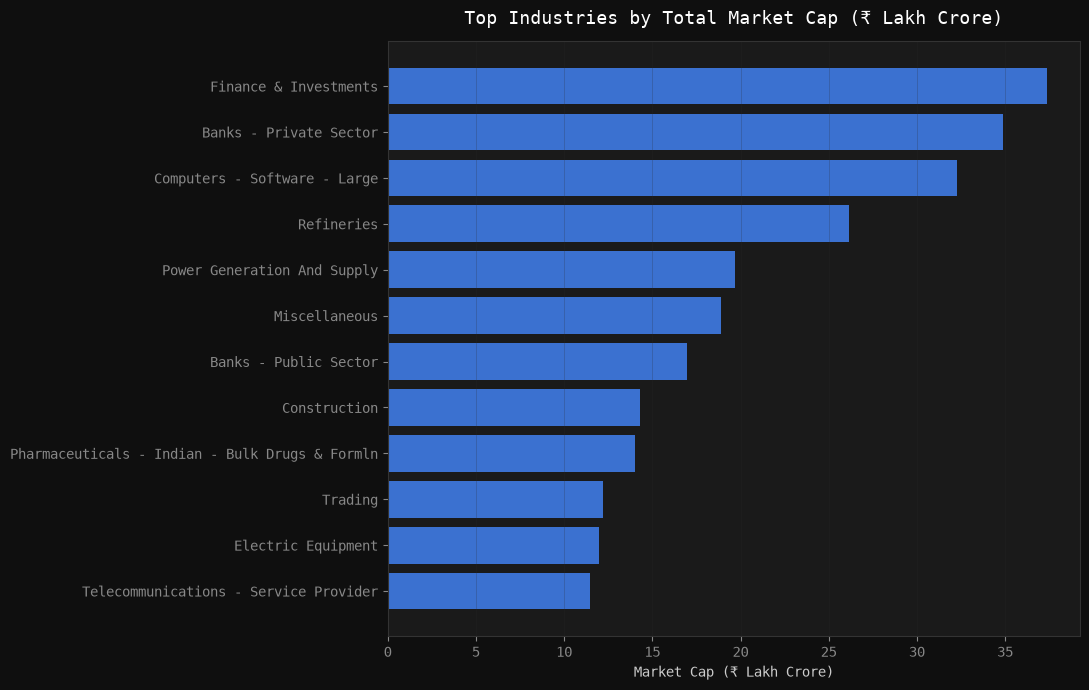

  💾 Saved → R:\AutoAnalyst\finance_module\outputs\charts\annual_p_l_1_final_02_profitability.png


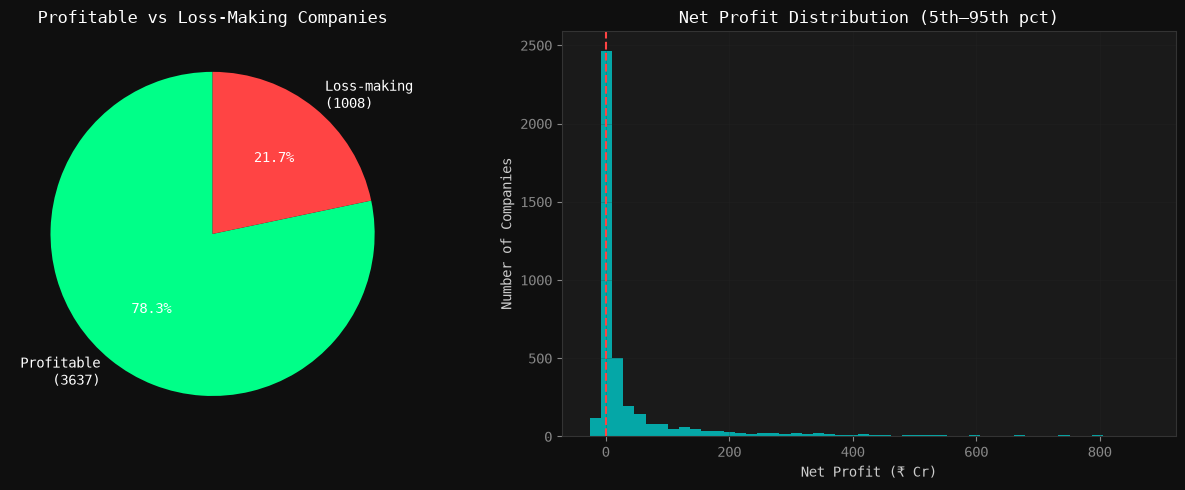

  💾 Saved → R:\AutoAnalyst\finance_module\outputs\charts\annual_p_l_1_final_03_eps.png


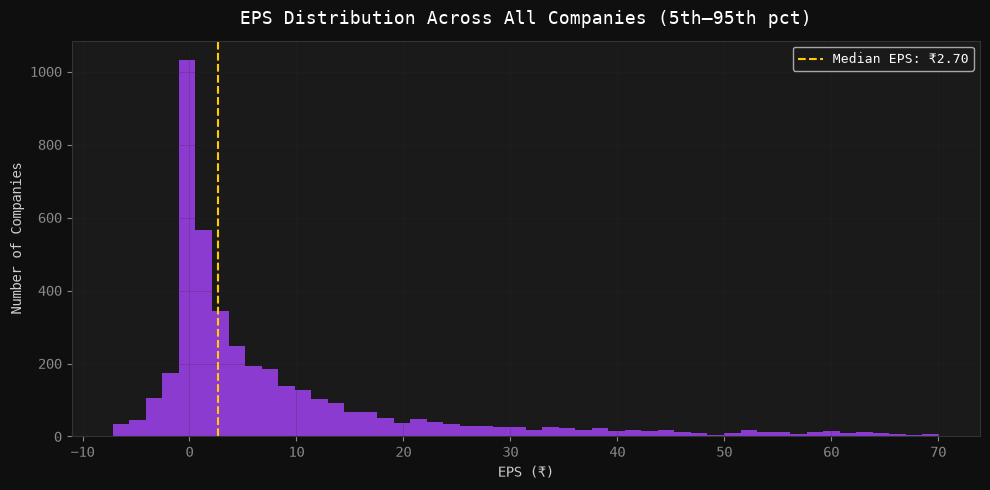

  💾 Saved → R:\AutoAnalyst\finance_module\outputs\charts\annual_p_l_1_final_04_top_companies.png


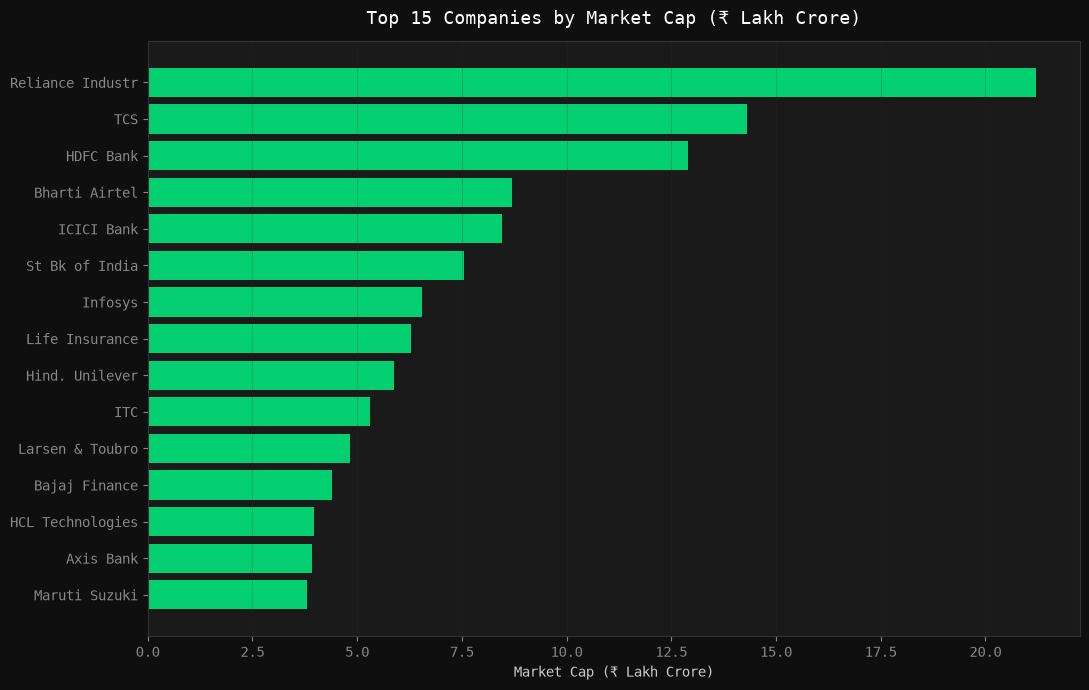

  💾 Saved → R:\AutoAnalyst\finance_module\outputs\charts\annual_p_l_1_final_05_opm_vs_marketcap.png


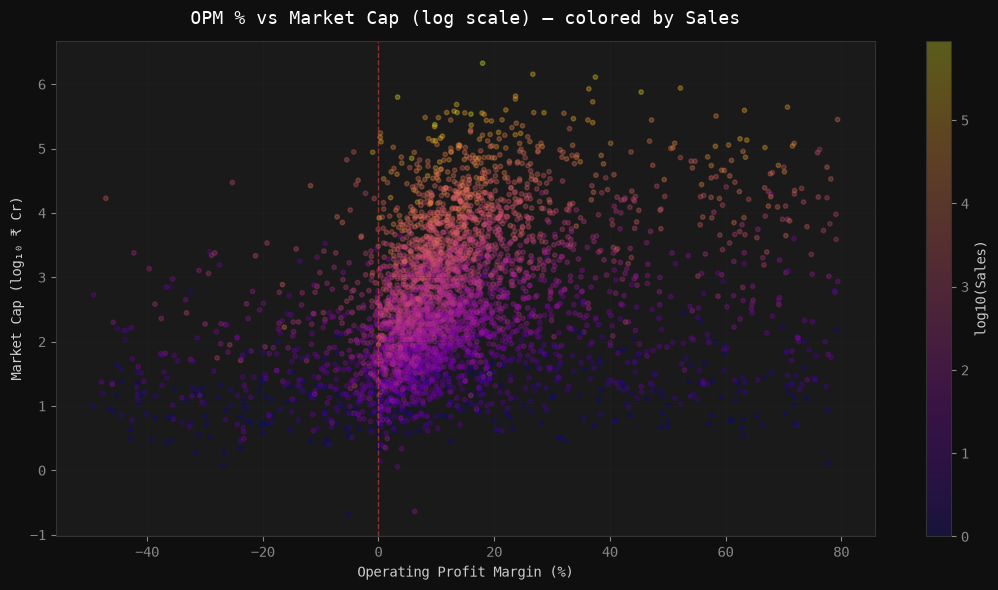


✅ All charts generated for FUNDAMENTAL dataset.


In [29]:
# ── Cell 5: Type-Specific Charts ──────────────────────────────────────────────

dataset_slug = DATASET_FILENAME.replace('.csv', '').replace(' ', '_').lower()

# ════════════════════════════════════════════════════════════
# TIMESERIES CHARTS
# ════════════════════════════════════════════════════════════
if dataset_type == 'timeseries':

    # ── Chart 1: Price + Moving Averages ─────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(df_clean['date'], df_clean['close'],
            color=COLORS['blue'], linewidth=1, label='Close', alpha=0.9)
    ax.plot(df_clean['date'], df_clean['ma_7'],
            color=COLORS['yellow'], linewidth=1.2, label='MA 7', alpha=0.8)
    ax.plot(df_clean['date'], df_clean['ma_30'],
            color=COLORS['orange'], linewidth=1.5, label='MA 30', alpha=0.9)
    ax.plot(df_clean['date'], df_clean['ma_90'],
            color=COLORS['purple'], linewidth=2, label='MA 90', alpha=0.9)
    ax.set_title('Price History + Moving Averages', fontsize=13, pad=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (₹)')
    ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    save_chart(fig, f'{dataset_slug}_01_price_ma')

    # ── Chart 2: Volume Bar Chart ─────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 4))
    colors  = [COLORS['green'] if r >= 0 else COLORS['red']
               for r in df_clean['daily_return'].fillna(0)]
    ax.bar(df_clean['date'], df_clean['volume'],
           color=colors, alpha=0.7, width=1)
    ax.set_title('Daily Volume (Green = Up Day, Red = Down Day)', fontsize=13, pad=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Volume')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    save_chart(fig, f'{dataset_slug}_02_volume')

    # ── Chart 3: Daily Returns Distribution ──────────────────
    returns = df_clean['daily_return'].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(returns, bins=60, color=COLORS['blue'],
                 alpha=0.8, edgecolor='none')
    axes[0].axvline(0, color=COLORS['gray'], linewidth=1, linestyle='--')
    axes[0].axvline(returns.mean(), color=COLORS['green'],
                    linewidth=1.5, linestyle='--', label=f'Mean: {returns.mean():.3f}%')
    axes[0].set_title('Daily Returns Distribution', fontsize=12)
    axes[0].set_xlabel('Daily Return (%)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Yearly returns bar
    yearly_ret = df_clean.groupby('year').apply(
        lambda x: (x['close'].iloc[-1] - x['close'].iloc[0]) / x['close'].iloc[0] * 100
    ).reset_index()
    yearly_ret.columns = ['year', 'return_pct']
    bar_colors = [COLORS['green'] if r >= 0 else COLORS['red']
                  for r in yearly_ret['return_pct']]
    axes[1].bar(yearly_ret['year'].astype(str),
                yearly_ret['return_pct'], color=bar_colors, alpha=0.85)
    axes[1].axhline(0, color=COLORS['gray'], linewidth=1)
    axes[1].set_title('Annual Returns (%)', fontsize=12)
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Return (%)')
    for i, (_, row) in enumerate(yearly_ret.iterrows()):
        axes[1].text(i, row['return_pct'] + (1 if row['return_pct'] >= 0 else -2.5),
                     f"{row['return_pct']:.1f}%",
                     ha='center', fontsize=8,
                     color=COLORS['green'] if row['return_pct'] >= 0 else COLORS['red'])
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    save_chart(fig, f'{dataset_slug}_03_returns')

    # ── Chart 4: Rolling Volatility ───────────────────────────
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(df_clean['date'], df_clean['volatility_30d'],
                    color=COLORS['orange'], alpha=0.4, label='30-day Volatility')
    ax.plot(df_clean['date'], df_clean['volatility_30d'],
            color=COLORS['orange'], linewidth=1)
    ax.axhline(df_clean['volatility_30d'].mean(),
               color=COLORS['yellow'], linewidth=1.5, linestyle='--',
               label=f'Avg: {df_clean["volatility_30d"].mean():.1f}%')
    ax.set_title('30-Day Rolling Volatility (Annualized %)', fontsize=13, pad=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Volatility (%)')
    ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    save_chart(fig, f'{dataset_slug}_04_volatility')

    # ── Chart 5: Correlation Heatmap ──────────────────────────
    num_cols = ['close', 'high', 'low', 'open', 'volume', 'daily_return']
    num_cols = [c for c in num_cols if c in df_clean.columns]
    corr     = df_clean[num_cols].corr()
    fig, ax  = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
                ax=ax, linewidths=0.5, linecolor='#111111',
                annot_kws={'size': 9},
                cbar_kws={'shrink': 0.8})
    ax.set_title('Correlation Heatmap', fontsize=13, pad=12)
    fig.tight_layout()
    save_chart(fig, f'{dataset_slug}_05_correlation')


# ════════════════════════════════════════════════════════════
# TRANSACTIONAL CHARTS
# ════════════════════════════════════════════════════════════
elif dataset_type == 'transactional':

    amount_col = 'amount'
    date_col   = 'date'

    # ── Chart 1: Spend by Category ────────────────────────────
    cat_spend = (df_clean.groupby('exp_type')[amount_col].sum()
                 .sort_values(ascending=True))
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(cat_spend.index, cat_spend.values / 1e7,
                   color=PALETTE[:len(cat_spend)], alpha=0.85)
    ax.set_title('Total Spend by Category (₹ Crore)', fontsize=13, pad=12)
    ax.set_xlabel('Spend (₹ Crore)')
    for bar, val in zip(bars, cat_spend.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'₹{val/1e7:.1f} Cr', va='center', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    fig.tight_layout()
    save_chart(fig, f'{dataset_slug}_01_category_spend')

    # ── Chart 2: Monthly Spend Trend ──────────────────────────
    monthly = (df_clean.groupby([df_clean[date_col].dt.to_period('M')])
               [amount_col].sum())
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(monthly.index.astype(str), monthly.values / 1e6,
            color=COLORS['teal'], linewidth=2, marker='o', markersize=3)
    ax.fill_between(range(len(monthly)), monthly.values / 1e6,
                    alpha=0.15, color=COLORS['teal'])
    ax.set_title('Monthly Spend Trend (₹ Million)', fontsize=13, pad=12)
    ax.set_xlabel('Month')
    ax.set_ylabel('Spend (₹ Million)')
    tick_step = max(1, len(monthly) // 12)
    ax.set_xticks(range(0, len(monthly), tick_step))
    ax.set_xticklabels(
        [str(monthly.index[i]) for i in range(0, len(monthly), tick_step)],
        rotation=45, ha='right', fontsize=7)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    save_chart(fig, f'{dataset_slug}_02_monthly_trend')

    # ── Chart 3: Card Type + Gender Split ─────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    card_spend = df_clean.groupby('card_type')[amount_col].sum().sort_values(ascending=False)
    axes[0].pie(card_spend.values,
                labels=card_spend.index,
                colors=PALETTE[:len(card_spend)],
                autopct='%1.1f%%', startangle=90,
                textprops={'color': 'white', 'fontsize': 9})
    axes[0].set_title('Spend by Card Type', fontsize=12)

    gender_spend = df_clean.groupby('gender')[amount_col].sum()
    axes[1].pie(gender_spend.values,
                labels=gender_spend.index,
                colors=[COLORS['blue'], COLORS['purple']],
                autopct='%1.1f%%', startangle=90,
                textprops={'color': 'white', 'fontsize': 10})
    axes[1].set_title('Spend by Gender', fontsize=12)

    fig.tight_layout()
    save_chart(fig, f'{dataset_slug}_03_card_gender')

    # ── Chart 4: Top Cities ───────────────────────────────────
    top_cities = (df_clean.groupby('city')[amount_col].sum()
                  .sort_values(ascending=True).tail(12))
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_cities.index, top_cities.values / 1e7,
                   color=COLORS['teal'], alpha=0.8)
    ax.set_title('Top Cities by Total Spend (₹ Crore)', fontsize=13, pad=12)
    ax.set_xlabel('Spend (₹ Crore)')
    ax.grid(True, alpha=0.3, axis='x')
    fig.tight_layout()
    save_chart(fig, f'{dataset_slug}_04_top_cities')

    # ── Chart 5: Day of Week Pattern ──────────────────────────
    dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    dow_spend = df_clean.groupby('day_of_week')[amount_col].mean()
    dow_spend = dow_spend.reindex([d for d in dow_order if d in dow_spend.index])
    fig, ax   = plt.subplots(figsize=(10, 5))
    bar_colors = [COLORS['green'] if v == dow_spend.max()
                  else COLORS['red'] if v == dow_spend.min()
                  else COLORS['blue'] for v in dow_spend.values]
    ax.bar(dow_spend.index, dow_spend.values / 1e3,
           color=bar_colors, alpha=0.85)
    ax.set_title('Avg Transaction Amount by Day of Week (₹ Thousands)', fontsize=13, pad=12)
    ax.set_xlabel('Day')
    ax.set_ylabel('Avg Amount (₹ K)')
    ax.grid(True, alpha=0.3, axis='y')
    fig.tight_layout()
    save_chart(fig, f'{dataset_slug}_05_day_of_week')


# ════════════════════════════════════════════════════════════
# FUNDAMENTAL CHARTS
# ════════════════════════════════════════════════════════════
elif dataset_type == 'fundamental':

    # ── Chart 1: Top Industries by Market Cap ─────────────────
    if 'industry' in df_clean.columns and 'market_capitalization' in df_clean.columns:
        ind_mc = (df_clean.groupby('industry')['market_capitalization']
                  .sum().sort_values(ascending=True).tail(12))
        fig, ax = plt.subplots(figsize=(11, 7))
        ax.barh(ind_mc.index, ind_mc.values / 1e5,
                color=COLORS['blue'], alpha=0.8)
        ax.set_title('Top Industries by Total Market Cap (₹ Lakh Crore)', fontsize=13, pad=12)
        ax.set_xlabel('Market Cap (₹ Lakh Crore)')
        ax.grid(True, alpha=0.3, axis='x')
        fig.tight_layout()
        save_chart(fig, f'{dataset_slug}_01_industry_marketcap')

    # ── Chart 2: Profitability Distribution ───────────────────
    profit_col = next((c for c in ['net_profit','profit_after_tax']
                       if c in df_clean.columns), None)
    if profit_col:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        # Pie: profitable vs loss-making
        profitable  = (df_clean[profit_col] > 0).sum()
        loss_making = (df_clean[profit_col] < 0).sum()
        axes[0].pie([profitable, loss_making],
                    labels=[f'Profitable\n({profitable})', f'Loss-making\n({loss_making})'],
                    colors=[COLORS['green'], COLORS['red']],
                    autopct='%1.1f%%', startangle=90,
                    textprops={'color': 'white', 'fontsize': 10})
        axes[0].set_title('Profitable vs Loss-Making Companies', fontsize=12)

        # Histogram: profit distribution (clip extremes for readability)
        profits = df_clean[profit_col].dropna()
        p5, p95 = profits.quantile(0.05), profits.quantile(0.95)
        clipped = profits[(profits >= p5) & (profits <= p95)]
        axes[1].hist(clipped, bins=50, color=COLORS['teal'], alpha=0.8, edgecolor='none')
        axes[1].axvline(0, color=COLORS['red'], linewidth=1.5, linestyle='--')
        axes[1].set_title('Net Profit Distribution (5th–95th pct)', fontsize=12)
        axes[1].set_xlabel('Net Profit (₹ Cr)')
        axes[1].set_ylabel('Number of Companies')
        axes[1].grid(True, alpha=0.3)
        fig.tight_layout()
        save_chart(fig, f'{dataset_slug}_02_profitability')

    # ── Chart 3: EPS Distribution ─────────────────────────────
    if 'eps' in df_clean.columns:
        eps = df_clean['eps'].dropna()
        p5, p95 = eps.quantile(0.05), eps.quantile(0.95)
        clipped_eps = eps[(eps >= p5) & (eps <= p95)]
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.hist(clipped_eps, bins=50, color=COLORS['purple'], alpha=0.8, edgecolor='none')
        ax.axvline(eps.median(), color=COLORS['yellow'], linewidth=1.5,
                   linestyle='--', label=f'Median EPS: ₹{eps.median():.2f}')
        ax.set_title('EPS Distribution Across All Companies (5th–95th pct)', fontsize=13, pad=12)
        ax.set_xlabel('EPS (₹)')
        ax.set_ylabel('Number of Companies')
        ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        save_chart(fig, f'{dataset_slug}_03_eps')

    # ── Chart 4: Top 15 Companies by Market Cap ───────────────
    if 'market_capitalization' in df_clean.columns and 'name' in df_clean.columns:
        top15 = (df_clean[['name', 'market_capitalization']]
                 .dropna().nlargest(15, 'market_capitalization'))
        fig, ax = plt.subplots(figsize=(11, 7))
        bars = ax.barh(top15['name'][::-1],
                       top15['market_capitalization'][::-1] / 1e5,
                       color=COLORS['green'], alpha=0.8)
        ax.set_title('Top 15 Companies by Market Cap (₹ Lakh Crore)', fontsize=13, pad=12)
        ax.set_xlabel('Market Cap (₹ Lakh Crore)')
        ax.grid(True, alpha=0.3, axis='x')
        fig.tight_layout()
        save_chart(fig, f'{dataset_slug}_04_top_companies')

    # ── Chart 5: OPM vs Market Cap scatter ────────────────────
    if all(c in df_clean.columns for c in ['opm', 'market_capitalization', 'sales']):
        plot_df = df_clean[['opm','market_capitalization','sales','name']].dropna()
        # Clip OPM extremes
        plot_df = plot_df[(plot_df['opm'] > -50) & (plot_df['opm'] < 80)]
        plot_df = plot_df[plot_df['market_capitalization'] > 0]
        fig, ax = plt.subplots(figsize=(11, 6))
        sc = ax.scatter(plot_df['opm'],
                        np.log10(plot_df['market_capitalization']),
                        alpha=0.3, s=10,
                        c=np.log10(plot_df['sales'].clip(lower=1)),
                        cmap='plasma')
        plt.colorbar(sc, ax=ax, label='log10(Sales)')
        ax.axvline(0, color=COLORS['red'], linewidth=1, linestyle='--', alpha=0.5)
        ax.set_title('OPM % vs Market Cap (log scale) — colored by Sales', fontsize=13, pad=12)
        ax.set_xlabel('Operating Profit Margin (%)')
        ax.set_ylabel('Market Cap (log₁₀ ₹ Cr)')
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        save_chart(fig, f'{dataset_slug}_05_opm_vs_marketcap')

print(f'\n✅ All charts generated for {dataset_type.upper()} dataset.')

In [30]:
# ── Cell 6: Chart Summary ─────────────────────────────────────────────────────
print('=' * 60)
print('  CHARTS GENERATED')
print('=' * 60)
for i, path in enumerate(chart_log, 1):
    print(f'  {i}. {os.path.basename(path)}')
print(f'\n  Total : {len(chart_log)} charts')
print(f'  Saved → {CHARTS_DIR}')
print('=' * 60)
print('\n✅ Visualization complete. Ready for 05_llm_insights.ipynb')

  CHARTS GENERATED
  1. annual_p_l_1_final_01_industry_marketcap.png
  2. annual_p_l_1_final_02_profitability.png
  3. annual_p_l_1_final_03_eps.png
  4. annual_p_l_1_final_04_top_companies.png
  5. annual_p_l_1_final_05_opm_vs_marketcap.png

  Total : 5 charts
  Saved → R:\AutoAnalyst\finance_module\outputs\charts

✅ Visualization complete. Ready for 05_llm_insights.ipynb


In [6]:
import pandas as pd

path = r"R:\AutoAnalyst\sports_module\datasets\f1\\"

races = pd.read_csv(path + 'races.csv')
lap_times = pd.read_csv(path + 'lap_times.csv')
pit_stops = pd.read_csv(path + 'pit_stops.csv')

print("Races year range:", races['year'].min(), "→", races['year'].max())
print("Total races:", len(races))

# Filter to modern era
modern_races = races[races['year'] >= 1994]
modern_raceIds = set(modern_races['raceId'])

print("\nModern era (1994+) races:", len(modern_races))

lap_modern = lap_times[lap_times['raceId'].isin(modern_raceIds)]
pit_modern = pit_stops[pit_stops['raceId'].isin(modern_raceIds)]

print("Lap times rows (modern):", len(lap_modern))
print("Pit stop rows (modern):", len(pit_modern))

# Check when pit stops data actually starts
pit_with_year = pit_stops.merge(races[['raceId','year']], on='raceId')
print("\nPit stops year range:", pit_with_year['year'].min(), "→", pit_with_year['year'].max())

Races year range: 1950 → 2024
Total races: 1125

Modern era (1994+) races: 577
Lap times rows (modern): 589081
Pit stop rows (modern): 11371

Pit stops year range: 2011 → 2024
